# PRC1.1: Data Augmentation for Image Classification with Albumentations (TASK 1)

**Goals:**
This notebook is part of the first programming assignment (PRC1) for the course "Deep Learning for Visual Signal Processing I." In this notebook, you are required to undertake a series of tasks listed in the "2.TASKS" section. These tasks involve working with a custom dataset derived from the  [Places dataset](http://places.csail.mit.edu/browser.html) and utilize the `Albumentations` library for data augmentation.

**Learning Objectives:**
* Engage with a hands-on tutorial on data augmentation using the `Albumentations` library.
* Develop a practical understanding of various data augmentation strategies and implement them effectively.
* Evaluate and clearly articulate the impact of these data augmentation strategies on your model's performance.


**Expected Outcomes:**
* Notebooks: Generate separate notebooks for each experiment conducted during this task.
* Report: Submit a concise report (no more than two pages) that adheres to the specified course format, summarizing your findings and analyses.

**Estimated Completion Time:** The tasks are designed to be completed within an estimated timeframe of 3-5 hours when using GPU acceleration.

---

Author1: Sabbatini, Andrea (andrea.sabbatini@estudiante.uam.es)

Author2: Hamdy, Adham (adham.hamdy@estudiante.uam.es)

Author3: Ciurescu, Irina Alexandra (irinaa.ciurescu@estudiante.uam.es)

---
###### Course: Deep Learning for Visual Signal Processing I
###### Master in [Artificial Intelligence for Image Processing and Computer Vision (IPCVai)](https://ipcv.eu/)
######  [Escuela Politécnica Superior](https://www.uam.es/EPS/Home.htm), [Universidad Autónoma de Madrid](https://www.uam.es/)


# 1.Codebase

It contains essential scripts to access the dataset and establish the training partitions required for the tasks.

### 1-1.Install the required libraries

The code works with the following versions

Python 3.10 or above \
Pytorch 2.5.1+cu121 \
Torchvision 0.20.1+cu121 \
Albumentations 2.0.3


In [37]:
!pip install albumentations==2.0.3

###  1-2.Dataset loading
We will work with the [Scenes15](http://www-vpu.eps.uam.es/~jcs/DLVSP1/dataset_scenes15.zip) dataset, which features a diverse set of images intended for scene recognition tasks. Below are the key characteristics of this dataset:

* Classes: 15 (Kitchen, Store, Bedroom, LivingRoom, Office, Industrial, Suburb, InsideCity, TallBuilding, Street, Highway, OpenCountry, Coast, Mountain, Forest)
* Total: 4,485 color RGB images
* Resolution: Images vary in resolution, adapting to different scene types and scales.

The following code downloads the dataset:

In [38]:
import os

# Download dataset
if os.path.isfile('dataset_scenes15.zip') == False:
  !wget http://www-vpu.eps.uam.es/~jcs/teaching/datasets/dataset_scenes15.zip 

# Uncompress dataset
if os.path.isdir('/scenes15') == False:
  !unzip -o -q dataset_scenes15.zip -d .

# Class labels correspond to the subdirectories of the root folder
!ls ./scenes15/

Bedroom  Highway     Kitchen	 Office       Street
Coast	 Industrial  LivingRoom  OpenCountry  Suburb
Forest	 InsideCity  Mountain	 Store	      TallBuilding


### 1-3.Dataset partition (Train and Test)
As the dataset downloaded is not partitioned into train y test, we do it via the **random_split** function

In [39]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split

# Load the dataset from the directory
dataset_scene15_dir = './scenes15/'
dataset_scene15 = datasets.ImageFolder(root=dataset_scene15_dir, transform=None)

# create the partitions for train and test
train_test_ratio=0.8
total_size = len(dataset_scene15)
train_size = int(train_test_ratio * total_size)
test_size = total_size - train_size
dataset_scene15_train, dataset_scene15_test = random_split(dataset_scene15,
                                                          [train_size, test_size] ,
                                                           generator=torch.Generator().manual_seed(42))
print(f"Partition: Train {len(dataset_scene15_train)} samples, Test {len(dataset_scene15_test)} samples")

Partition: Train 3588 samples, Test 897 samples


### 1-4.Model
We will define a simple CNN obtained by adjusting the one found in the tutorial.

In [40]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(512 * 8 * 8, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 15)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.pool(self.relu(self.conv4(x)))
        x = x.view(-1, 512 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# 2.Data augmentation
We use the `Albumentations` library, as explored in the tutorial, to define the data augmentation transformations. To manage computational resources effectively, we incorporate a *Resize* transformation to standardize image dimensions to 128x128 for training.

### 2-1.Transformation definition
The following code defines a function used to get one of the tested augmentation.

In [62]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

def get_augmentation(name: str):
    """Return an Albumentations Compose for the given augmentation name.

    All pipelines:
    - resize to 128x128
    - convert to float in [0,1] (ToFloat(max_value=255.0))
    - convert to PyTorch tensor (ToTensorV2)
    """
    name = name.lower().strip()

    if name == "base":
        return A.Compose([
            A.Resize(width=128, height=128),
            A.ToFloat(max_value=255.0),
            ToTensorV2(),
        ])

    if name == "rotate":
        return A.Compose([
            A.Resize(width=128, height=128),
            A.ToFloat(max_value=255.0),
            A.Rotate(limit=5, p=0.5),
            ToTensorV2(),
        ])

    if name == "hflip":
        return A.Compose([
            A.Resize(width=128, height=128),
            A.ToFloat(max_value=255.0),
            A.HorizontalFlip(p=0.5),
            ToTensorV2(),
        ])

    if name == "randomresizedcrop":
        return A.Compose([
            A.Resize(width=128, height=128),
            A.ToFloat(max_value=255.0),
            A.RandomResizedCrop(size=(128,128), scale=(0.8,1.0), ratio=(0.9,1.1), p=0.8),
            ToTensorV2(),
        ])

    if name == "colorjitter":
        return A.Compose([
            A.Resize(width=128, height=128),
            A.ToFloat(max_value=255.0),
            A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, p=0.5),
            ToTensorV2(),
        ])

    if name== "invertimg":
        return A.Compose([
            A.Resize(width=128, height=128),
            A.ToFloat(max_value=255.0),
            A.InvertImg(p=0.2),
            ToTensorV2(),
        ])

    raise ValueError(
        f"Unknown augmentation: {name}. Use one of: base, colorjitter, hflip, randomresizedcrop, rotate, invertimg"
    )

### 2-2.Integrate Data Augmentation with PyTorch DataLoader¶
Once we defined our data augmentation transformations using the `Albumentations` library, we will need to apply these transformations to the partitions of the dataset we have downloaded. Below is the code snippet that will help integrate the transformations with the dataset partitions:

In [42]:
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import numpy as np
import matplotlib.pyplot as plt

class DatasetAlbumentations:
    """Wrap a torchvision dataset to apply Albumentations transforms."""
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        image = np.array(image)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        return image, label

def make_datasets(train_aug_name: str, test_aug_name: str = "base"):
    """Create train/test datasets with the requested Albumentations pipelines."""
    train_aug = get_augmentation(train_aug_name)
    test_aug  = get_augmentation(test_aug_name)

    train_ds = DatasetAlbumentations(dataset_scene15_train, transform=train_aug)
    test_ds  = DatasetAlbumentations(dataset_scene15_test,  transform=test_aug)
    return train_ds, test_ds

# Default datasets used by the demo/visualization cells below
train_dataset, test_dataset = make_datasets("base", "base")

Use the following code to display some images...

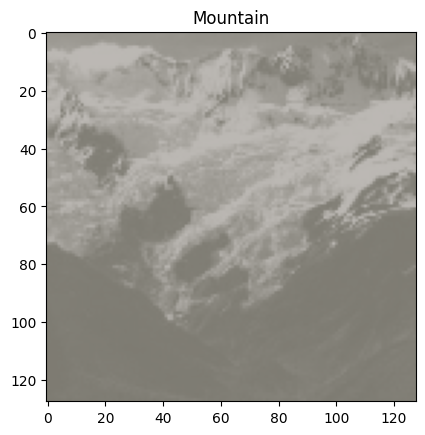

In [43]:
def imshow(img, label):
    """Imshow for Tensor."""
    img = img.numpy().transpose((1, 2, 0))  # Convert from Tensor image
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.247, 0.243, 0.261])
    img = std * img + mean  # Unnormalize
    img = np.clip(img, 0, 1)  # Clip to ensure [0, 1] range
    plt.imshow(img)
    plt.title(label)
    plt.show()

# Get data to display
image, label = train_dataset[0]

# Convert class indexes to class labels for display
class_labels = dataset_scene15.classes  # Assuming your ImageFolder has a 'classes' attribute

# Show images with labels
label_str = class_labels[label]  # Get the corresponding label
imshow(image, label_str)  # Call the function to display the image and label

# 3. Experiment: 6 Independent Training Runs (20 Epochs) with Different Augmentations

Below we perform **6 separate training runs**, each of **20 epochs**, and **each time we start from scratch** (new model, new optimizer, same hyperparameters).

For each augmentation we show:

- the log lines for every epoch (Loss / Train Acc / Test Acc)  
- **a loss plot** (train/test loss vs epoch)  
- the **confusion matrix** on the test and training sets (often referred to here as the *transition matrix*)
- some images from the augmented dataset

### 3-1.Settings
We define the needed functions.

In [44]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ----------------------------
# Experiment settings
# ----------------------------
torch.manual_seed(0)  # reproducibility of weight init / dataloader shuffling
num_workers = 4
num_epochs  = 20
batch_size  = 64
lr          = 1e-3
weight_decay= 1e-5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Class names (from ImageFolder)
CLASS_NAMES = dataset_scene15.classes
assert len(CLASS_NAMES) == 15, f"Expected 15 classes, got {len(CLASS_NAMES)}"

def calculate_accuracy(loader, model):
    """Return accuracy (%) + true labels + predicted labels for the given loader."""
    correct, total = 0, 0
    all_labels, all_preds = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
    acc = 100.0 * correct / max(total, 1)
    return acc, np.array(all_labels), np.array(all_preds)

def evaluate_loss_accuracy(loader, model, criterion):
    """Return avg loss, accuracy (%), true labels, predicted labels."""
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    all_labels, all_preds = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())

    avg_loss = running_loss / max(len(loader.dataset), 1)
    acc = 100.0 * correct / max(total, 1)
    return avg_loss, acc, np.array(all_labels), np.array(all_preds)

# ----------------------------
# 6 independent runs
# ----------------------------
def run(aug_name, aug_number, batch_size, num_workers):
    print("\n" + "="*90)
    print(f"RUN {aug_number}/6  |  Training augmentation: {aug_name}")
    print("="*90)
    
    # Build datasets and dataloaders (fresh for each run)
    train_dataset, test_dataset = make_datasets(train_aug_name=aug_name, test_aug_name=aug_name)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=num_workers)
    
    # Fresh model / loss / optimizer (restart from scratch)
    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    
    # Training
    train_losses = []
    test_losses  = []
    train_accs   = []
    test_accs    = []
    
    print(f"Running training in {device} mode for {num_epochs} epochs")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
    
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
    
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item() * images.size(0)
    
        train_epoch_loss = running_loss / max(len(train_loader.dataset), 1)
        train_losses.append(train_epoch_loss)
    
        # Evaluate epoch (loss + accuracy)
        train_eval_loss, train_accuracy, _, _ = evaluate_loss_accuracy(train_loader, model, criterion)
        test_eval_loss,  test_accuracy,  _, _ = evaluate_loss_accuracy(test_loader,  model, criterion)
    
        # We keep the training loss computed during the update steps, and track test loss separately
        test_losses.append(test_eval_loss)
        train_accs.append(train_accuracy)
        test_accs.append(test_accuracy)

        print(
            f"Epoch [{epoch+1}/{num_epochs}], "
            f"Train Loss: {train_epoch_loss:.4f}, Test Loss: {test_eval_loss:.4f}, "
            f"Train Accuracy: {train_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%"
        )
    
    # ----------------------------
    # Loss curve (train vs test)
    # ----------------------------
    plt.figure(figsize=(6,4))
    epochs = range(1, num_epochs+1)
    plt.plot(epochs, train_losses, label="Train loss")
    plt.plot(epochs, test_losses,  label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss curve (train vs test) - augmentation: {aug_name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    # ----------------------------
    # Confusion matrices (TRAIN + TEST)
    # ----------------------------
    _, _, train_labels, train_preds = evaluate_loss_accuracy(train_loader, model, criterion)
    _, _, test_labels,  test_preds  = evaluate_loss_accuracy(test_loader,  model, criterion)
    
    cm_train = confusion_matrix(train_labels, train_preds)
    disp_tr = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp_tr.plot(ax=ax, xticks_rotation=45, cmap=None, colorbar=False)
    ax.set_title(f"Confusion matrix (TRAIN) - augmentation: {aug_name}")
    plt.show()
    
    cm_test = confusion_matrix(test_labels, test_preds)
    disp_te = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp_te.plot(ax=ax, xticks_rotation=45, cmap=None, colorbar=False)
    ax.set_title(f"Confusion matrix (TEST) - augmentation: {aug_name}")
    plt.show()

    # ----------------------------
    # Display some images from the augmented dataset
    # ----------------------------
    def visualize(images, title=""):
        images = images.cpu().numpy()
        fig, axs = plt.subplots(1, 5, figsize=(15, 3))
        for i, ax in enumerate(axs):
            ax.imshow(np.transpose(images[i], (1, 2, 0)))
            ax.axis('off')
        plt.suptitle(title)
        plt.show()

    images, _ = next(iter(train_loader))
    visualize(images[:5], "Sample augmented images")

Device: cuda


### 3-2.Base
We train the dataset without applying particular augmentations.


RUN 1/6  |  Training augmentation: base
Running training in cuda mode for 20 epochs
Epoch [1/20], Train Loss: 2.6446, Test Loss: 2.3730, Train Accuracy: 20.01%, Test Accuracy: 19.18%
Epoch [2/20], Train Loss: 2.2752, Test Loss: 2.0842, Train Accuracy: 31.58%, Test Accuracy: 28.21%
Epoch [3/20], Train Loss: 2.0410, Test Loss: 1.8582, Train Accuracy: 41.95%, Test Accuracy: 37.68%
Epoch [4/20], Train Loss: 1.7700, Test Loss: 1.6023, Train Accuracy: 51.81%, Test Accuracy: 46.04%
Epoch [5/20], Train Loss: 1.4933, Test Loss: 1.3442, Train Accuracy: 61.51%, Test Accuracy: 54.29%
Epoch [6/20], Train Loss: 1.2844, Test Loss: 1.3375, Train Accuracy: 62.90%, Test Accuracy: 56.52%
Epoch [7/20], Train Loss: 1.1427, Test Loss: 1.2058, Train Accuracy: 71.43%, Test Accuracy: 59.98%
Epoch [8/20], Train Loss: 1.0147, Test Loss: 1.2411, Train Accuracy: 73.30%, Test Accuracy: 59.53%
Epoch [9/20], Train Loss: 0.9045, Test Loss: 1.1029, Train Accuracy: 81.05%, Test Accuracy: 63.88%
Epoch [10/20], Train Los

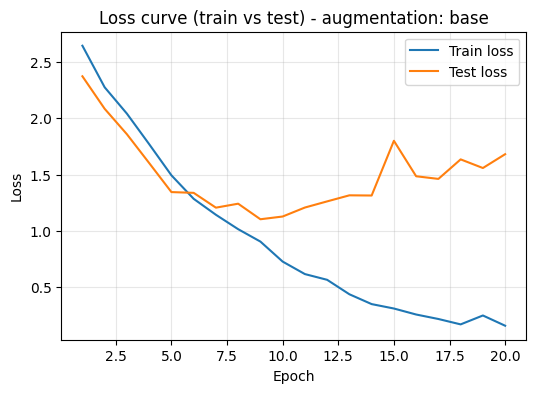

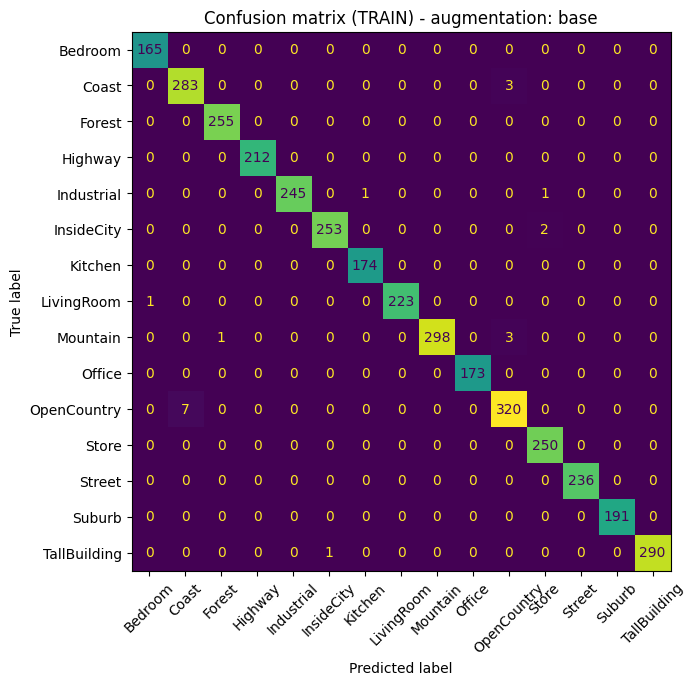

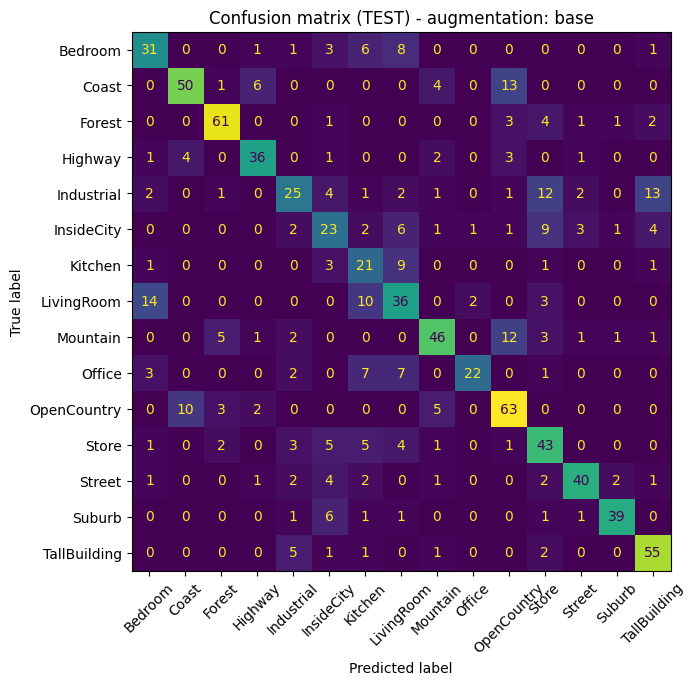

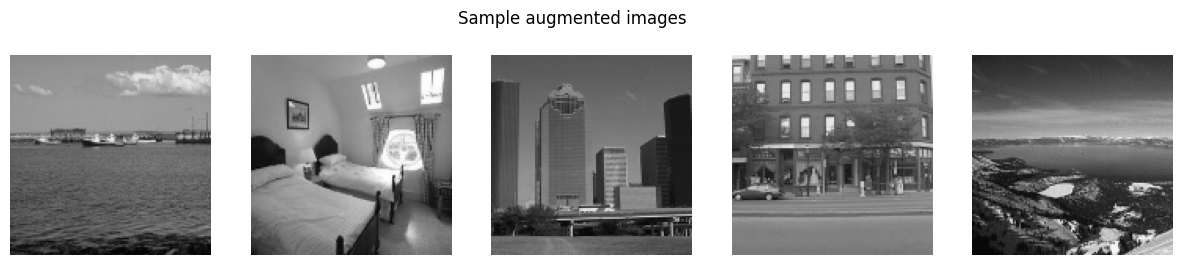

In [47]:
run("base", 1, batch_size, num_workers)

### 3-3.Horizontal Flip
Horizontally flips the image left-to-right, mirroring it along the vertical axis.


RUN 2/6  |  Training augmentation: hflip
Running training in cuda mode for 20 epochs
Epoch [1/20], Train Loss: 2.6502, Test Loss: 2.4032, Train Accuracy: 18.14%, Test Accuracy: 17.50%
Epoch [2/20], Train Loss: 2.2790, Test Loss: 2.1407, Train Accuracy: 30.71%, Test Accuracy: 28.32%
Epoch [3/20], Train Loss: 2.0846, Test Loss: 1.9639, Train Accuracy: 35.14%, Test Accuracy: 33.11%
Epoch [4/20], Train Loss: 1.8709, Test Loss: 1.7376, Train Accuracy: 44.76%, Test Accuracy: 40.13%
Epoch [5/20], Train Loss: 1.5503, Test Loss: 1.3938, Train Accuracy: 56.52%, Test Accuracy: 52.51%
Epoch [6/20], Train Loss: 1.4026, Test Loss: 1.4218, Train Accuracy: 53.90%, Test Accuracy: 51.62%
Epoch [7/20], Train Loss: 1.3666, Test Loss: 1.2706, Train Accuracy: 62.37%, Test Accuracy: 57.41%
Epoch [8/20], Train Loss: 1.1756, Test Loss: 1.1406, Train Accuracy: 66.78%, Test Accuracy: 59.87%
Epoch [9/20], Train Loss: 1.1135, Test Loss: 1.1364, Train Accuracy: 67.17%, Test Accuracy: 59.64%
Epoch [10/20], Train Lo

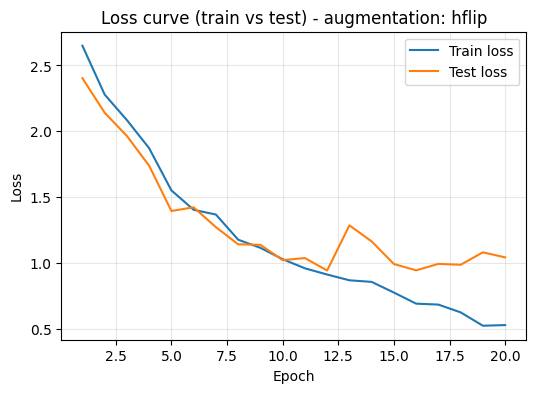

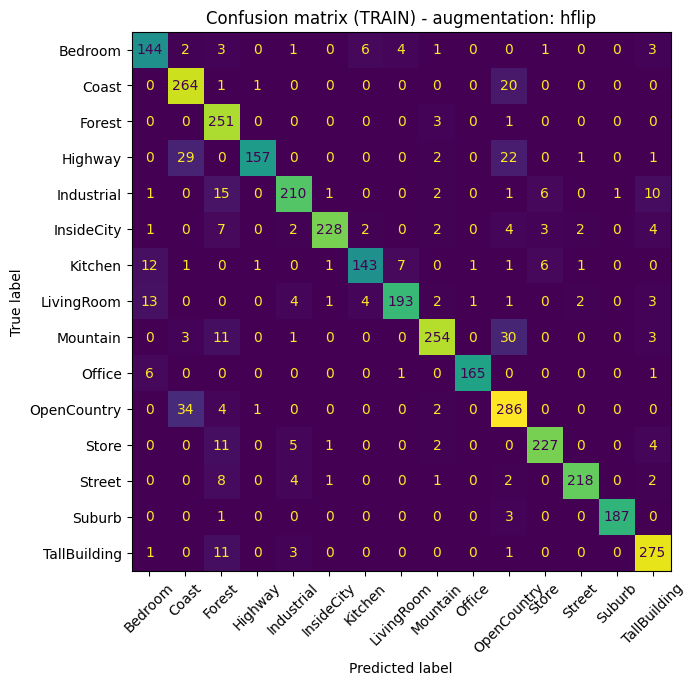

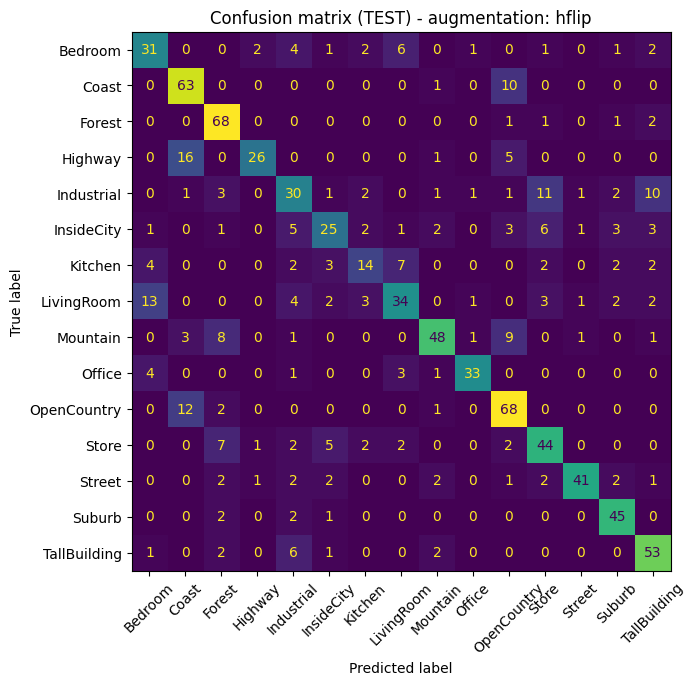

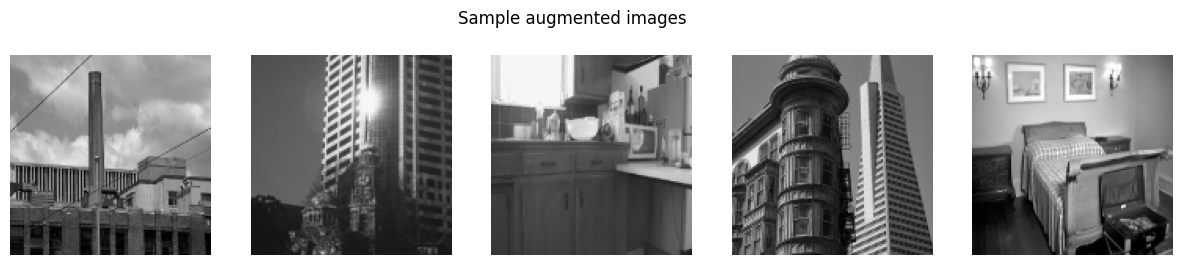

In [48]:
run("hflip", 2, batch_size, num_workers)

### 3-4.Color Jitter
Changes the light and the contrast.


RUN 3/6  |  Training augmentation: colorjitter
Running training in cuda mode for 20 epochs
Epoch [1/20], Train Loss: 2.6829, Test Loss: 2.4793, Train Accuracy: 17.87%, Test Accuracy: 17.95%
Epoch [2/20], Train Loss: 2.2998, Test Loss: 2.0621, Train Accuracy: 30.77%, Test Accuracy: 28.76%
Epoch [3/20], Train Loss: 2.0346, Test Loss: 1.8683, Train Accuracy: 36.04%, Test Accuracy: 33.11%
Epoch [4/20], Train Loss: 1.7330, Test Loss: 1.5607, Train Accuracy: 50.56%, Test Accuracy: 47.05%
Epoch [5/20], Train Loss: 1.5140, Test Loss: 1.4072, Train Accuracy: 56.22%, Test Accuracy: 52.62%
Epoch [6/20], Train Loss: 1.3382, Test Loss: 1.3124, Train Accuracy: 61.26%, Test Accuracy: 56.08%
Epoch [7/20], Train Loss: 1.2183, Test Loss: 1.2586, Train Accuracy: 64.38%, Test Accuracy: 57.86%
Epoch [8/20], Train Loss: 1.0944, Test Loss: 1.2814, Train Accuracy: 64.02%, Test Accuracy: 57.08%
Epoch [9/20], Train Loss: 0.9842, Test Loss: 1.1218, Train Accuracy: 74.16%, Test Accuracy: 62.21%
Epoch [10/20], Tr

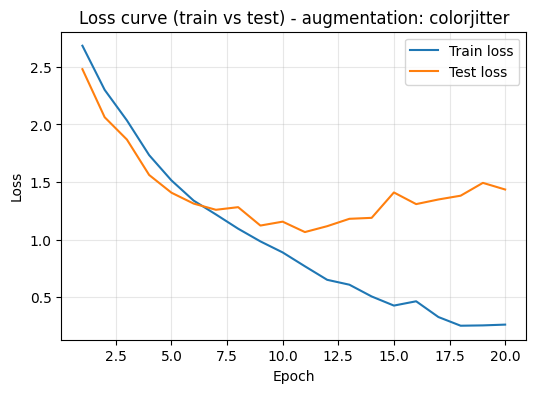

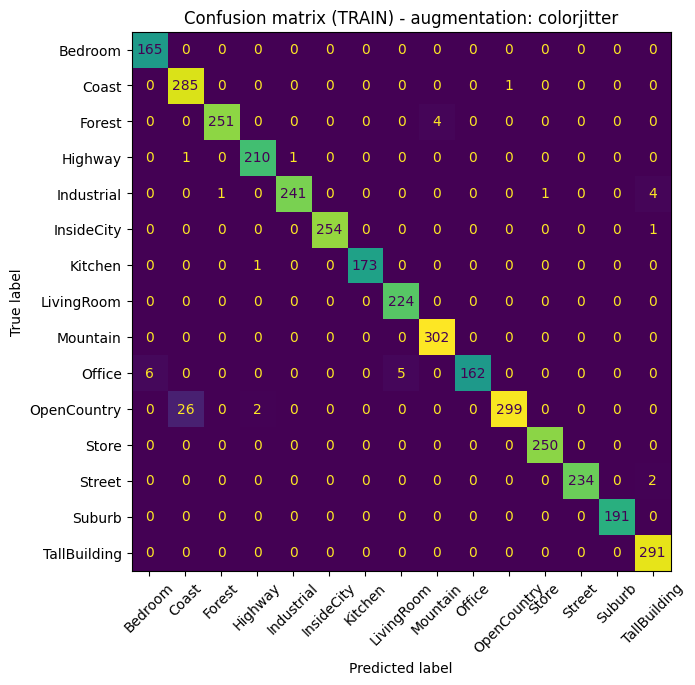

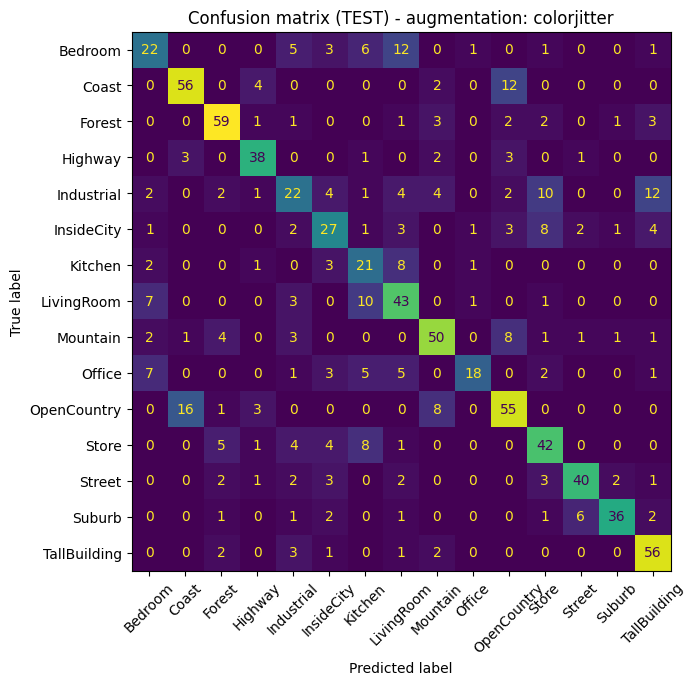

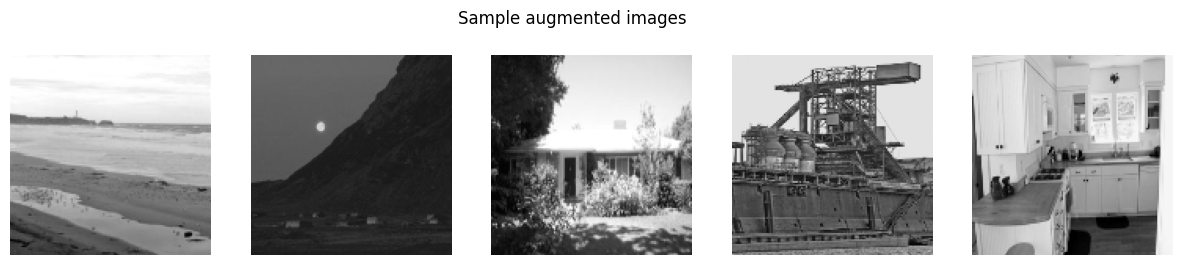

In [50]:
run("colorjitter", 3, batch_size, num_workers)

### 3-5.Rotate
Applies a light rotation.


RUN 4/6  |  Training augmentation: rotate
Running training in cuda mode for 20 epochs
Epoch [1/20], Train Loss: 2.6869, Test Loss: 2.6441, Train Accuracy: 13.32%, Test Accuracy: 14.49%
Epoch [2/20], Train Loss: 2.4776, Test Loss: 2.2756, Train Accuracy: 23.22%, Test Accuracy: 22.85%
Epoch [3/20], Train Loss: 2.1707, Test Loss: 2.0876, Train Accuracy: 32.53%, Test Accuracy: 30.55%
Epoch [4/20], Train Loss: 1.9792, Test Loss: 1.8229, Train Accuracy: 41.86%, Test Accuracy: 38.02%
Epoch [5/20], Train Loss: 1.6840, Test Loss: 1.5647, Train Accuracy: 49.39%, Test Accuracy: 47.16%
Epoch [6/20], Train Loss: 1.4602, Test Loss: 1.4526, Train Accuracy: 57.19%, Test Accuracy: 50.50%
Epoch [7/20], Train Loss: 1.3122, Test Loss: 1.1930, Train Accuracy: 67.59%, Test Accuracy: 59.98%
Epoch [8/20], Train Loss: 1.1485, Test Loss: 1.2563, Train Accuracy: 66.86%, Test Accuracy: 58.31%
Epoch [9/20], Train Loss: 1.0628, Test Loss: 1.2071, Train Accuracy: 69.93%, Test Accuracy: 60.20%
Epoch [10/20], Train L

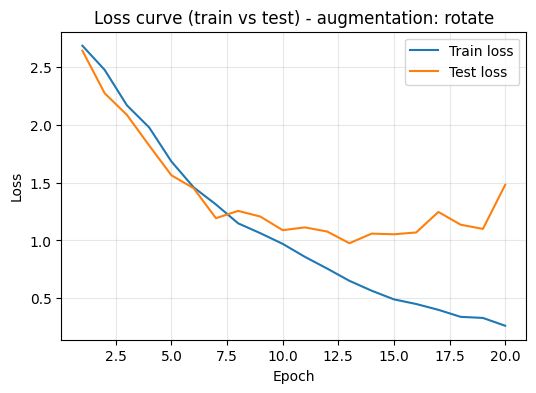

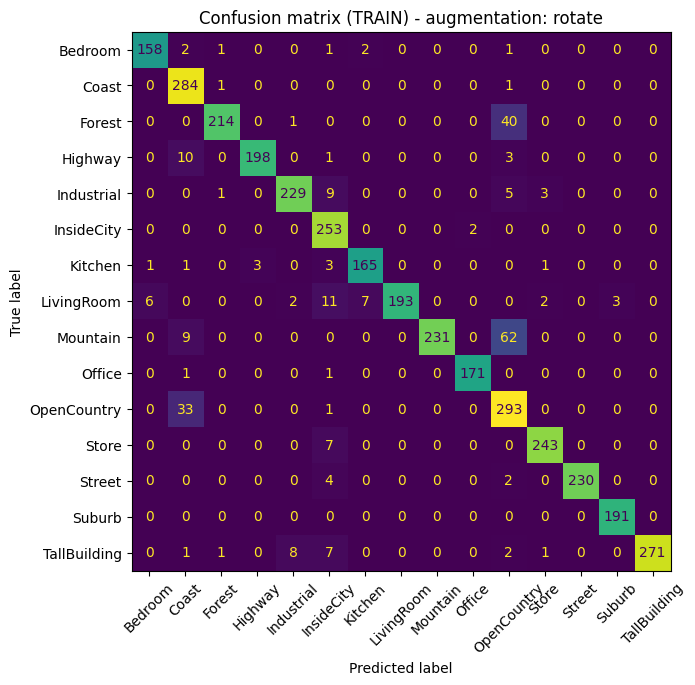

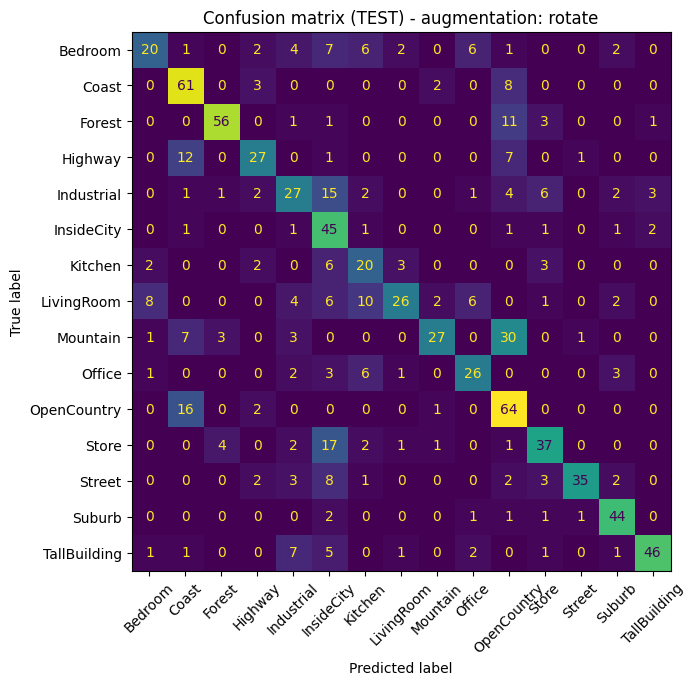

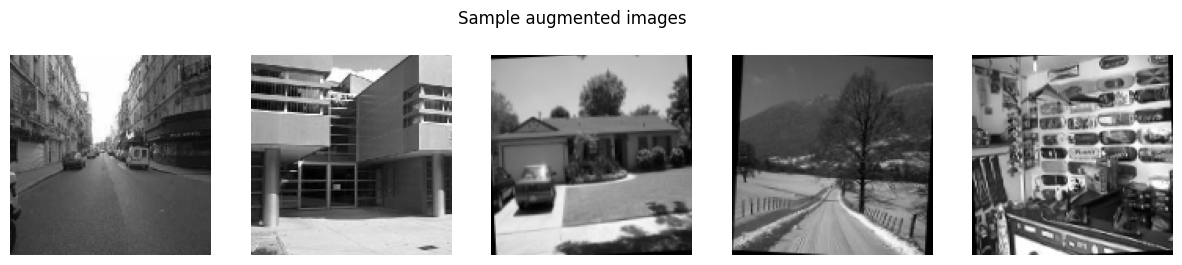

In [51]:
run("rotate", 4, batch_size, num_workers)

### 3-6.Random Resized Crop
Randomly crops a portion of the image at a random scale and aspect ratio, then resizes it to the target size.


RUN 5/6  |  Training augmentation: randomresizedcrop
Running training in cuda mode for 20 epochs
Epoch [1/20], Train Loss: 2.6997, Test Loss: 2.6809, Train Accuracy: 8.84%, Test Accuracy: 8.14%
Epoch [2/20], Train Loss: 2.5209, Test Loss: 2.2725, Train Accuracy: 26.14%, Test Accuracy: 25.98%
Epoch [3/20], Train Loss: 2.2189, Test Loss: 2.0898, Train Accuracy: 31.38%, Test Accuracy: 28.76%
Epoch [4/20], Train Loss: 2.0655, Test Loss: 2.1510, Train Accuracy: 31.47%, Test Accuracy: 30.88%
Epoch [5/20], Train Loss: 1.9206, Test Loss: 1.7413, Train Accuracy: 45.43%, Test Accuracy: 41.03%
Epoch [6/20], Train Loss: 1.7239, Test Loss: 1.7039, Train Accuracy: 43.92%, Test Accuracy: 39.91%
Epoch [7/20], Train Loss: 1.5365, Test Loss: 1.4065, Train Accuracy: 56.30%, Test Accuracy: 53.07%
Epoch [8/20], Train Loss: 1.3622, Test Loss: 1.3303, Train Accuracy: 59.34%, Test Accuracy: 54.29%
Epoch [9/20], Train Loss: 1.3000, Test Loss: 1.2423, Train Accuracy: 63.02%, Test Accuracy: 57.97%
Epoch [10/20]

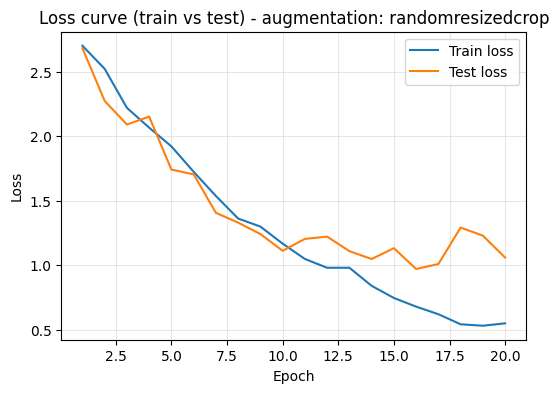

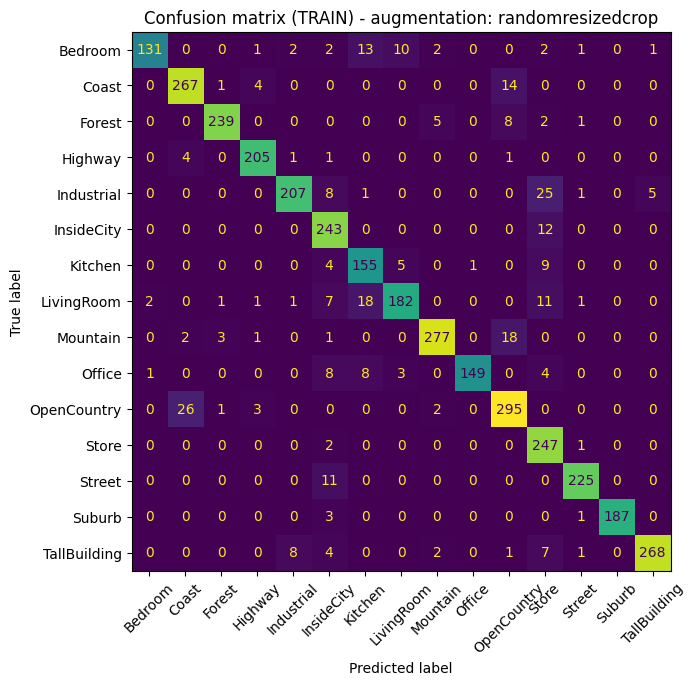

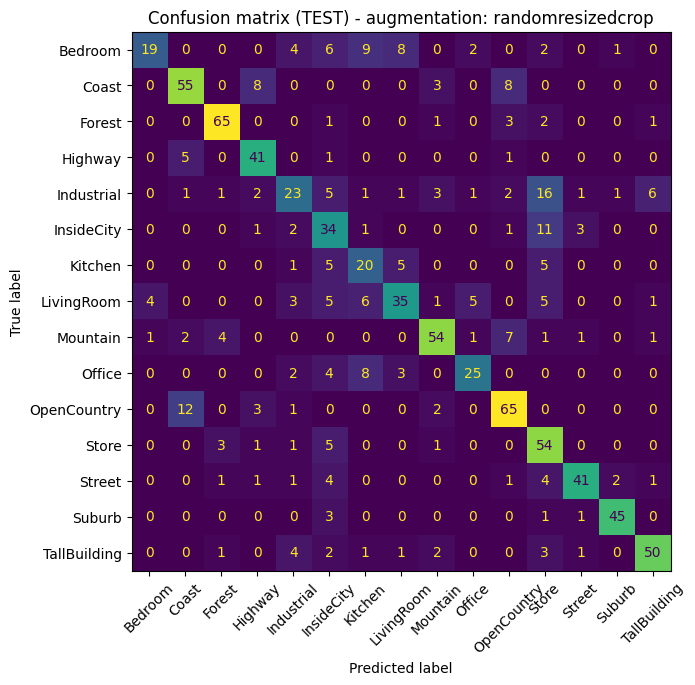

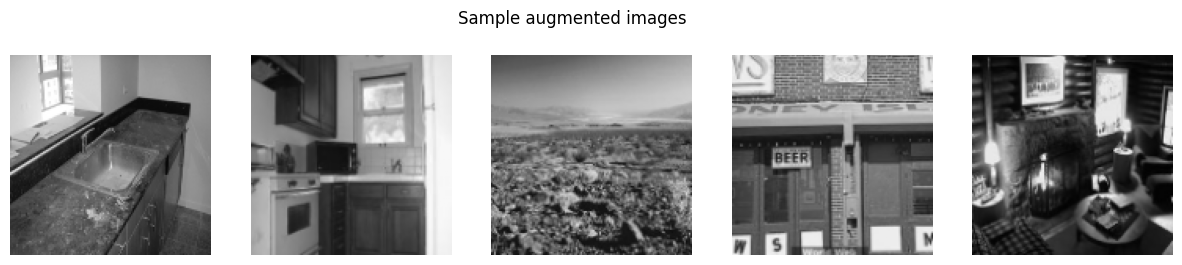

In [54]:
run("randomresizedcrop", 5, batch_size, num_workers)

### 3-7.Invert Image

Inverts the image colors with a low probability.


RUN 6/6  |  Training augmentation: invertimg
Running training in cuda mode for 20 epochs
Epoch [1/20], Train Loss: 2.7025, Test Loss: 2.6903, Train Accuracy: 9.11%, Test Accuracy: 9.25%
Epoch [2/20], Train Loss: 2.6887, Test Loss: 2.6426, Train Accuracy: 10.28%, Test Accuracy: 10.14%
Epoch [3/20], Train Loss: 2.5198, Test Loss: 2.2319, Train Accuracy: 26.20%, Test Accuracy: 25.64%
Epoch [4/20], Train Loss: 2.1730, Test Loss: 2.1044, Train Accuracy: 31.58%, Test Accuracy: 33.33%
Epoch [5/20], Train Loss: 1.8525, Test Loss: 2.0460, Train Accuracy: 36.23%, Test Accuracy: 34.34%
Epoch [6/20], Train Loss: 1.6659, Test Loss: 1.5262, Train Accuracy: 52.56%, Test Accuracy: 50.72%
Epoch [7/20], Train Loss: 1.4445, Test Loss: 1.3908, Train Accuracy: 57.33%, Test Accuracy: 55.07%
Epoch [8/20], Train Loss: 1.3411, Test Loss: 1.2421, Train Accuracy: 62.63%, Test Accuracy: 57.75%
Epoch [9/20], Train Loss: 1.1978, Test Loss: 1.1650, Train Accuracy: 64.94%, Test Accuracy: 61.20%
Epoch [10/20], Train 

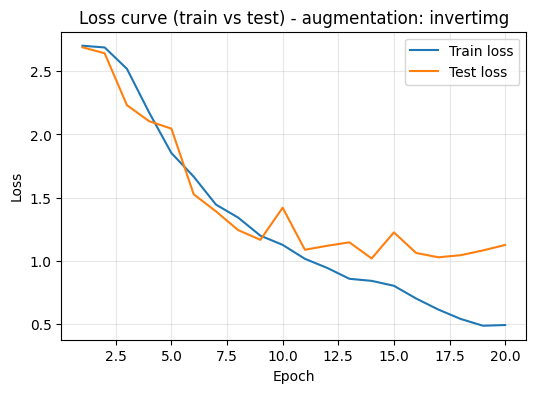

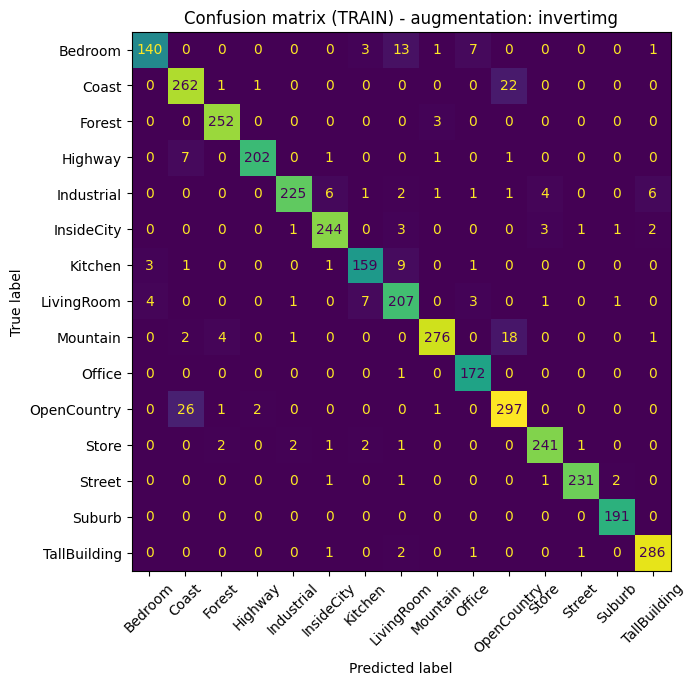

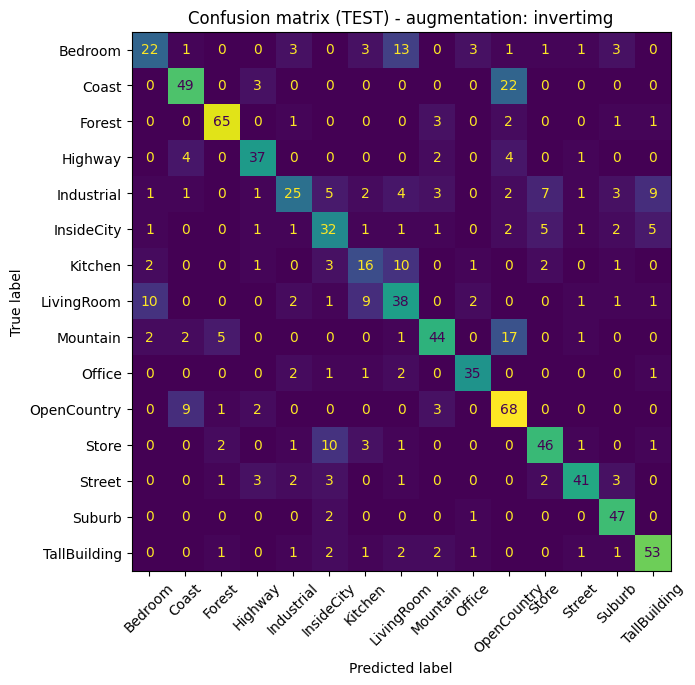

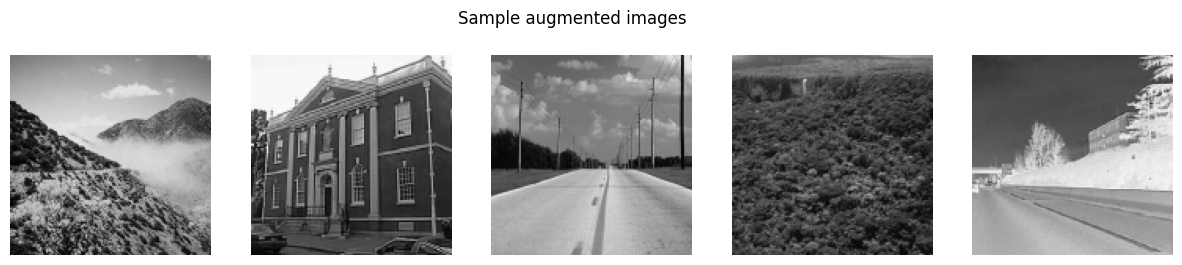

In [63]:
run("invertimg", 6, batch_size, num_workers)